# Minería de Datos en Python – Predicción de Abandono de Clientes (BankChurners)

**Integrantes:** Sebastian Muñoz · Santiago Martinez · Carlos Baena

**Datos:** [Credit Card Customers (Kaggle)](https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers) · 10.127 clientes de tarjeta de crédito, 23 columnas.

**Contenido**
1. Objetivo del modelo
2. Preparación de datos
   * 2.1 Diagnóstico de calidad de datos
3. (A) Selección de factores
4. Balanceo y codificación
5. (B) Validación cruzada de 6 modelos + revisión de overfitting / underfitting
6. (C) Hiperparametrización del mejor modelo con GridSearchCV
   * 6.1 Validación honesta (sin datos sintéticos en test)
7. Modelo final y guardado
8. (D) Despliegue con Streamlit
9. Conclusiones finales y limitaciones

# 1. Objetivo del modelo

El banco quiere **anticipar qué clientes de tarjeta de crédito van a abandonar** (`Attrition_Flag = Attrited Customer`) para
ofrecerles acciones de retención antes de que se vayan.

* **Tipo de problema:** clasificación binaria (Attrited Customer vs Existing Customer).
* **Variable objetivo:** `Attrition_Flag`.
* **Reto:** la base está desbalanceada (≈16 % de clientes que abandonan), por eso se balancea con SMOTE y se evalúa con
  **f1_macro** (promedia el f1 de ambas clases y no se deja engañar por la clase mayoritaria). También se reporta el
  **recall de la clase abandono**: para el negocio es más costoso no detectar a un cliente que se va que contactar a uno que se queda.

In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica
import warnings
warnings.filterwarnings('ignore')

# 2. Preparación de datos

In [ ]:
#Cargamos los datos
data = pd.read_csv("BankChurners.csv")
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
#Eliminamos variables irrelevantes: identificador del cliente y dos columnas que son salidas de un modelo Naive Bayes
#(contienen la respuesta, usarlas sería hacer trampa)
data = data.drop([
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
], axis=1)
data.shape

(10127, 20)

In [ ]:
#Corrección de tipos de datos
for col in ['Attrition_Flag','Gender','Education_Level','Marital_Status','Income_Category','Card_Category']:
    data[col] = data[col].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Attrition_Flag            10127 non-null  category
 1   Customer_Age              10127 non-null  int64   
 2   Gender                    10127 non-null  category
 3   Dependent_count           10127 non-null  int64   
 4   Education_Level           10127 non-null  category
 5   Marital_Status            10127 non-null  category
 6   Income_Category           10127 non-null  category
 7   Card_Category             10127 non-null  category
 8   Months_on_book            10127 non-null  int64   
 9   Total_Relationship_Count  10127 non-null  int64   
 10  Months_Inactive_12_mon    10127 non-null  int64   
 11  Contacts_Count_12_mon     10127 non-null  int64   
 12  Credit_Limit              10127 non-null  float64 
 13  Total_Revolving_Bal       10127 non-null  int6

In [ ]:
#Datos faltantes
data.isnull().sum().sum()

np.int64(0)

In [ ]:
#Descripción de variables numéricas
data.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


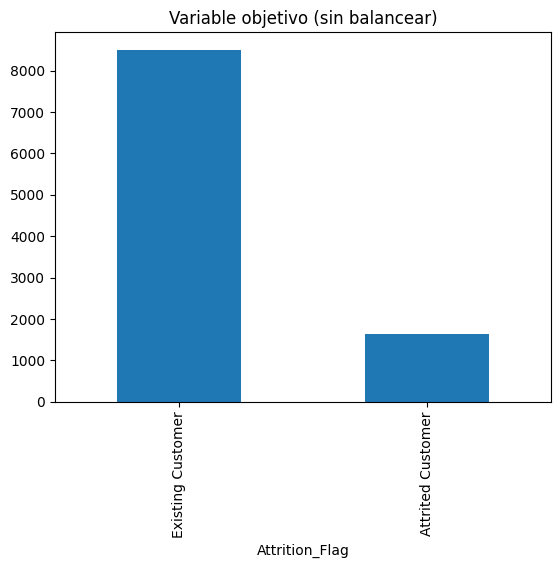

,proportion
Attrition_Flag,
Existing Customer,0.83934
Attrited Customer,0.16066


In [ ]:
#Descripción de la variable objetivo
data['Attrition_Flag'].value_counts().plot(kind='bar', title='Variable objetivo (sin balancear)')
plt.show()
data['Attrition_Flag'].value_counts(normalize=True)

## 2.1 Diagnóstico de calidad de datos

Antes de modelar se revisan las **seis dimensiones de calidad** sobre la base original completa (23 columnas, antes de eliminar
nada): completitud, unicidad, validez, consistencia, exactitud y oportunidad. Las tres primeras celdas miden; la tabla final resume
el diagnóstico y la decisión que se tomó en cada caso.

In [ ]:
#Base original completa (antes de eliminar columnas)
raw = pd.read_csv("BankChurners.csv")
print("Filas x columnas:", raw.shape)

#COMPLETITUD - nulos formales
print("Nulos formales (NaN):", raw.isnull().sum().sum())

#COMPLETITUD - nulos "disfrazados": la categoría 'Unknown' es en realidad un dato faltante
cats = ['Education_Level','Marital_Status','Income_Category']
unknown = pd.DataFrame({'registros Unknown': [(raw[c]=='Unknown').sum() for c in cats]}, index=cats)
unknown['% del total'] = (unknown['registros Unknown']/len(raw)*100).round(1)
con_unknown = (raw[cats]=='Unknown').any(axis=1)
print(f"Registros con al menos un 'Unknown': {con_unknown.sum()} ({con_unknown.mean():.1%})")
unknown

Filas x columnas: (10127, 23)
Nulos formales (NaN): 0
Registros con al menos un 'Unknown': 3046 (30.1%)


,registros Unknown,% del total
Education_Level,1519,15.0
Marital_Status,749,7.4
Income_Category,1112,11.0


In [ ]:
#UNICIDAD
print("Filas duplicadas completas:", raw.duplicated().sum())
print("CLIENTNUM repetidos       :", raw['CLIENTNUM'].duplicated().sum())

#VALIDEZ - rangos permitidos y categorías esperadas
print("Valores negativos en columnas numéricas:", (raw.select_dtypes('number') < 0).sum().sum())
print("Gender:", sorted(raw['Gender'].unique()), "| Card_Category:", sorted(raw['Card_Category'].unique()))
raw[['Customer_Age','Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon',
     'Contacts_Count_12_mon','Avg_Utilization_Ratio']].agg(['min','max']).T

Filas duplicadas completas: 0
CLIENTNUM repetidos       : 0
Valores negativos en columnas numéricas: 0
Gender: ['F', 'M'] | Card_Category: ['Blue', 'Gold', 'Platinum', 'Silver']


,min,max
Customer_Age,26.0,73.000
Months_on_book,13.0,56.000
Total_Relationship_Count,1.0,6.000
Months_Inactive_12_mon,0.0,6.000
Contacts_Count_12_mon,0.0,6.000
Avg_Utilization_Ratio,0.0,0.999


In [ ]:
#CONSISTENCIA - relaciones que deben cumplirse entre columnas
dif_cupo = (raw['Credit_Limit'] - (raw['Avg_Open_To_Buy'] + raw['Total_Revolving_Bal'])).abs().max()
dif_util = (raw['Total_Revolving_Bal']/raw['Credit_Limit'] - raw['Avg_Utilization_Ratio']).abs().max()
print("Credit_Limit = Avg_Open_To_Buy + Total_Revolving_Bal -> diferencia máxima:", round(dif_cupo, 4))
print("Avg_Utilization_Ratio = Total_Revolving_Bal / Credit_Limit -> diferencia máxima:", round(dif_util, 4), "(redondeo)")

#CONSISTENCIA - columnas que contienen la respuesta (fuga de datos)
cols_nb = [c for c in raw.columns if c.startswith('Naive_Bayes')]
print("\nColumnas con salida de un modelo Naive Bayes:", len(cols_nb))
raw.groupby('Attrition_Flag')[cols_nb[0]].mean().round(4).rename('valor medio de la 1a columna Naive Bayes')

Credit_Limit = Avg_Open_To_Buy + Total_Revolving_Bal -> diferencia máxima: 0.0
Avg_Utilization_Ratio = Total_Revolving_Bal / Credit_Limit -> diferencia máxima: 0.0005 (redondeo)

Columnas con salida de un modelo Naive Bayes: 2


,valor medio de la 1a columna Naive Bayes
Attrition_Flag,
Attrited Customer,0.9949
Existing Customer,0.0002


In [ ]:
#EXACTITUD - valores atípicos (regla del rango intercuartílico, 1.5 × IQR)
numericas = ['Customer_Age','Months_on_book','Credit_Limit','Total_Trans_Amt','Total_Trans_Ct',
             'Total_Amt_Chng_Q4_Q1','Total_Ct_Chng_Q4_Q1']
def atipicos(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

tabla_atipicos = pd.DataFrame({'atípicos': [atipicos(raw[c]) for c in numericas]}, index=numericas)
tabla_atipicos['% del total'] = (tabla_atipicos['atípicos']/len(raw)*100).round(1)
tabla_atipicos

,atípicos,% del total
Customer_Age,2,0.0
Months_on_book,386,3.8
Credit_Limit,984,9.7
Total_Trans_Amt,896,8.8
Total_Trans_Ct,2,0.0
Total_Amt_Chng_Q4_Q1,396,3.9
Total_Ct_Chng_Q4_Q1,394,3.9


**Diagnóstico de las dimensiones de calidad**

| Dimensión | Hallazgo | Decisión |
|---|---|---|
| **Completitud** | 0 nulos formales, pero `Education_Level` (15,0 %), `Income_Category` (11,0 %) y `Marital_Status` (7,4 %) traen la categoría `Unknown`: 3.046 registros (30,1 %) tienen al menos una. Es faltante disfrazado. | No se imputan: en la selección de factores (sección 3) las tres variables resultan irrelevantes y se descartan, así que el faltante no entra al modelo. |
| **Unicidad** | 0 filas duplicadas y 0 `CLIENTNUM` repetidos: cada fila es un cliente distinto. | Nada que depurar. Se elimina `CLIENTNUM` por ser solo un identificador. |
| **Validez** | Tipos coherentes (se pasan 6 columnas a `category`), sin valores negativos, rangos plausibles (edad 26–73, productos 1–6, meses inactivo 0–6, utilización entre 0 y 1) y solo las categorías esperadas. | Se corrigen los tipos de dato. |
| **Consistencia** | `Credit_Limit = Avg_Open_To_Buy + Total_Revolving_Bal` se cumple exactamente (redundancia por fórmula) y la utilización coincide con saldo / cupo (salvo redondeo). Además, **2 columnas son la salida de un modelo Naive Bayes** y traen la respuesta: fuga de datos. | Se elimina `Avg_Open_To_Buy` por redundante y se eliminan las 2 columnas Naive Bayes por fuga. |
| **Exactitud** | Hay atípicos por IQR en `Credit_Limit` (9,7 %) y `Total_Trans_Amt` (8,8 %), y en las variables de cambio Q4/Q1 y antigüedad (≈4 %). Son valores posibles (clientes de cupo alto, tarjetas Gold/Platinum), no errores. La exactitud frente a la fuente real no se puede verificar (dataset público). | Se conservan los atípicos: los modelos de árboles, que resultan los mejores, no son sensibles a ellos. |
| **Oportunidad** | La base no trae fecha; solo compara el cuarto trimestre con el primero de un periodo de 12 meses que no se identifica. | Se asume una foto única de la cartera. Es una limitación para el despliegue (sección 9). |

**Además:** la variable objetivo está **desbalanceada** (83,9 % `Existing Customer` vs 16,1 % `Attrited Customer`), lo que se trata con SMOTE en la sección 4.

# 3. (A) Selección de factores

Se siguen los pasos del notebook de *Selección de Factores*:
1. Se convierten todas las variables a número (dummies; las de 2 categorías con `drop_first=True`, las de 3 o más con `drop_first=False`).
2. **Correlaciones entre predictoras** → detectar variables **redundantes** (|r| > 0.8).
3. **Correlaciones con la variable de interés** → detectar variables **relevantes**.
4. Como las correlaciones solo capturan relaciones *lineales*, se complementa con la **importancia de variables de un Random Forest**, que captura relaciones no lineales.

* No se normaliza (la correlación no depende de la escala).

In [ ]:
# Transformaciones: convertimos a número todas las variables (incluyendo la objetivo)
data_num = pd.get_dummies(data, columns=['Education_Level','Marital_Status','Income_Category','Card_Category'], drop_first=False, dtype=int) #3 o más categorías: no se borra
data_num = pd.get_dummies(data_num, columns=['Gender','Attrition_Flag'], drop_first=True, dtype=int) #2 categorías: sí se borra
#Se deja la objetivo como 1 = abandona, para que la correlación se lea en el sentido del negocio
data_num['Abandono'] = 1 - data_num['Attrition_Flag_Existing Customer']
data_num = data_num.drop('Attrition_Flag_Existing Customer', axis=1)
data_num.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Gender_M,Abandono
0,45,3,39,5,1,3,12691.0,777,11914.0,1.335,...,1,0,0,0,1,0,0,0,1,0
1,49,5,44,6,1,2,8256.0,864,7392.0,1.541,...,0,0,1,0,1,0,0,0,0,0
2,51,3,36,4,1,0,3418.0,0,3418.0,2.594,...,0,1,0,0,1,0,0,0,1,0
3,40,4,34,3,4,1,3313.0,2517,796.0,1.405,...,0,0,1,0,1,0,0,0,0,0
4,40,3,21,5,1,0,4716.0,0,4716.0,2.175,...,1,0,0,0,1,0,0,0,1,0


## 3.1 Correlaciones entre predictoras: redundancias

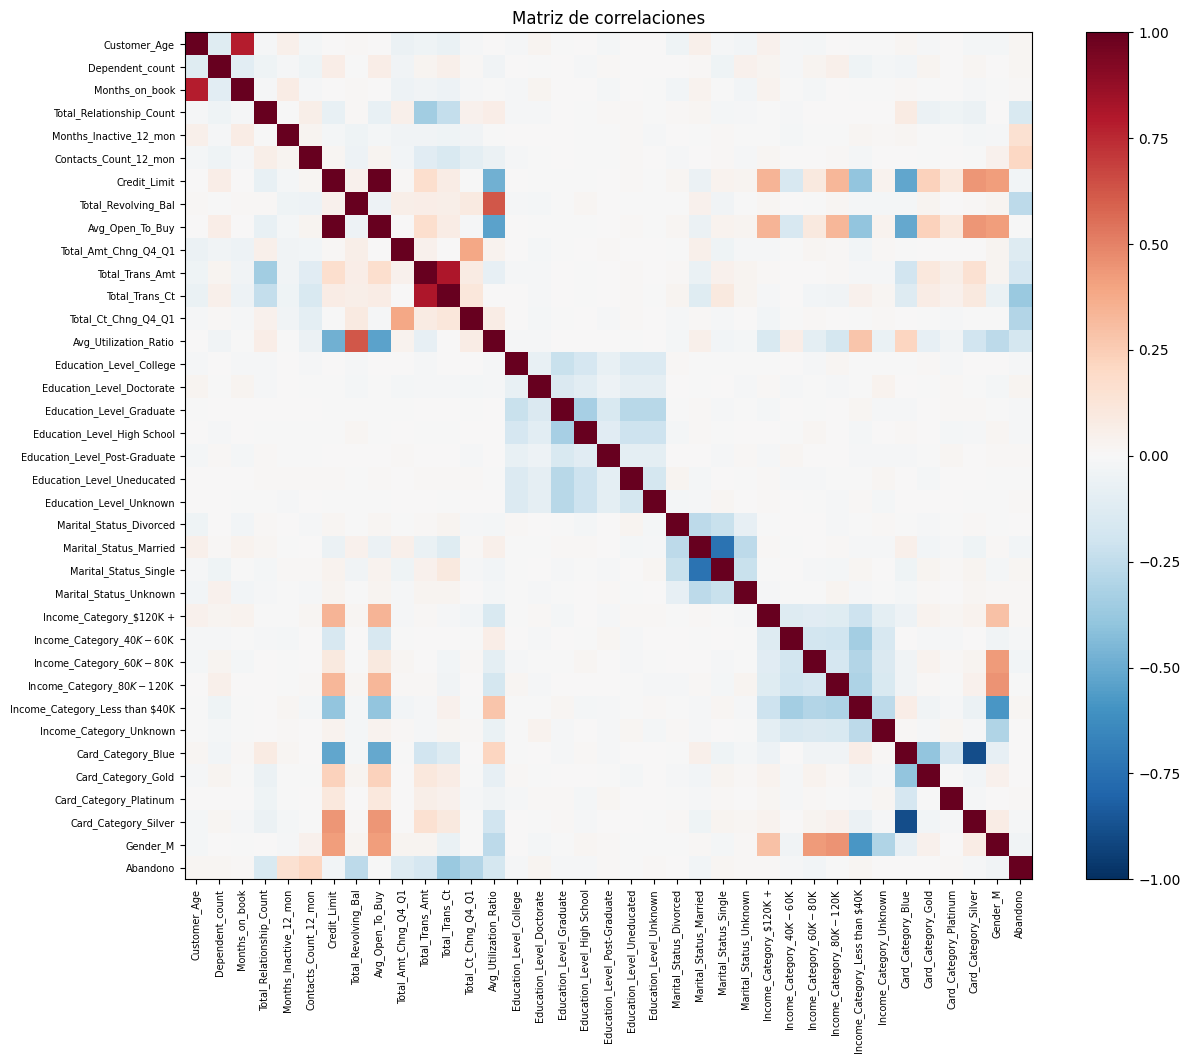

In [ ]:
# Correlaciones
correlaciones = data_num.corr()

plt.figure(figsize=(14,11))
plt.imshow(correlaciones, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(correlaciones)), correlaciones.columns, rotation=90, fontsize=7)
plt.yticks(range(len(correlaciones)), correlaciones.columns, fontsize=7)
plt.title('Matriz de correlaciones')
plt.show()

In [ ]:
#Pares de variables con correlación alta (posibles redundancias)
pares = correlaciones.abs().where(np.triu(np.ones(correlaciones.shape), k=1).astype(bool)).stack()
pares = pares.sort_values(ascending=False)
pares.head(8)

,,0
Credit_Limit,Avg_Open_To_Buy,0.995981
Card_Category_Blue,Card_Category_Silver,0.889816
Total_Trans_Amt,Total_Trans_Ct,0.807192
Customer_Age,Months_on_book,0.788912
Marital_Status_Married,Marital_Status_Single,0.741185
Total_Revolving_Bal,Avg_Utilization_Ratio,0.624022
Income_Category_Less than $40K,Gender_M,0.580016
Avg_Open_To_Buy,Avg_Utilization_Ratio,0.538808


In [ ]:
#Comprobación: Credit_Limit es exactamente la suma de Avg_Open_To_Buy + Total_Revolving_Bal (redundancia por fórmula)
(data['Credit_Limit'] - (data['Avg_Open_To_Buy'] + data['Total_Revolving_Bal'])).abs().max()

0.0

**Interpretación de redundancias**

* `Credit_Limit` y `Avg_Open_To_Buy` tienen correlación ≈ 0.996 y además la celda anterior muestra que
  `Credit_Limit = Avg_Open_To_Buy + Total_Revolving_Bal`. Son **redundantes**: se elimina `Avg_Open_To_Buy`.
* `Total_Trans_Amt` y `Total_Trans_Ct` (≈ 0.81) están apenas por encima del umbral. Se **conservan ambas** porque miden cosas
  distintas (monto vs número de transacciones) y, como se verá, son las dos variables más importantes del problema.
* `Card_Category_Blue` y `Card_Category_Silver` (≈ 0.89) son dummies de la misma variable (casi todos los clientes son Blue);
  no es una redundancia real y además `Card_Category` resulta irrelevante.
* `Customer_Age` y `Months_on_book` (≈ 0.79) están cerca del umbral: los clientes mayores llevan más tiempo en el banco.
  Se conserva la edad, que es más fácil de capturar en el despliegue.

## 3.2 Correlaciones con la variable de interés: relevancia

In [ ]:
#Correlaciones con la variable de interés
cor_variable_interes = correlaciones['Abandono'].drop('Abandono').sort_values()
cor_variable_interes

,Abandono
Total_Trans_Ct,-0.371403
Total_Ct_Chng_Q4_Q1,-0.290054
Total_Revolving_Bal,-0.263053
Avg_Utilization_Ratio,-0.178410
Total_Trans_Amt,-0.168598
Total_Relationship_Count,-0.150005
Total_Amt_Chng_Q4_Q1,-0.131063
Gender_M,-0.037272
Income_Category_$60K - $80K,-0.028221
Credit_Limit,-0.023873


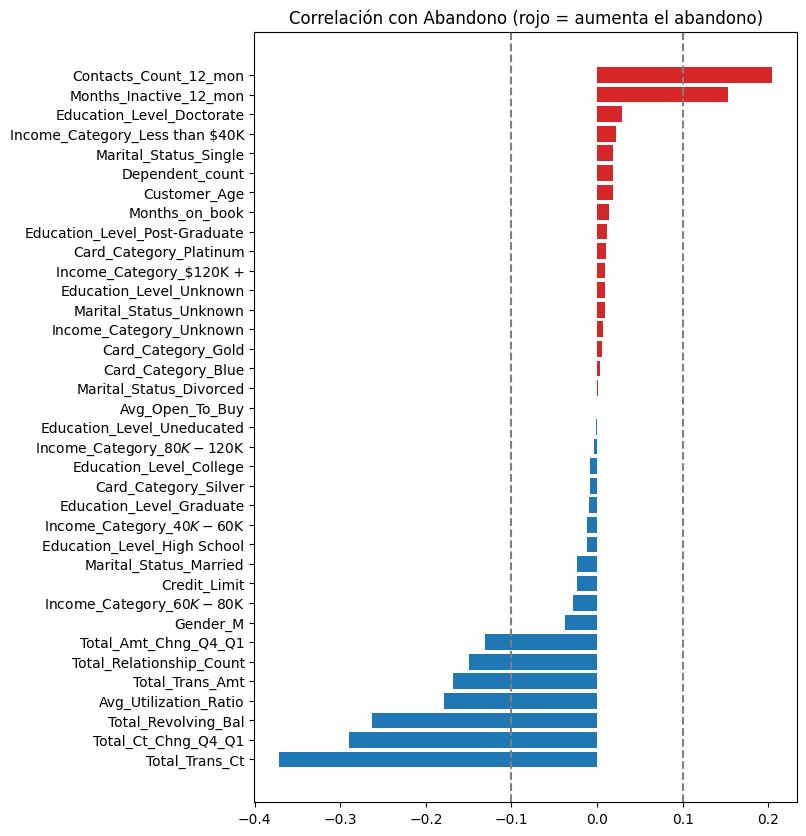

In [ ]:
plt.figure(figsize=(7,10))
colores = ['tab:red' if v > 0 else 'tab:blue' for v in cor_variable_interes]
plt.barh(y=cor_variable_interes.index, width=cor_variable_interes, color=colores)
plt.axvline(0.1, ls='--', c='gray'); plt.axvline(-0.1, ls='--', c='gray')
plt.title('Correlación con Abandono (rojo = aumenta el abandono)')
plt.show()

## 3.3 Importancia de variables con Random Forest (relaciones no lineales)

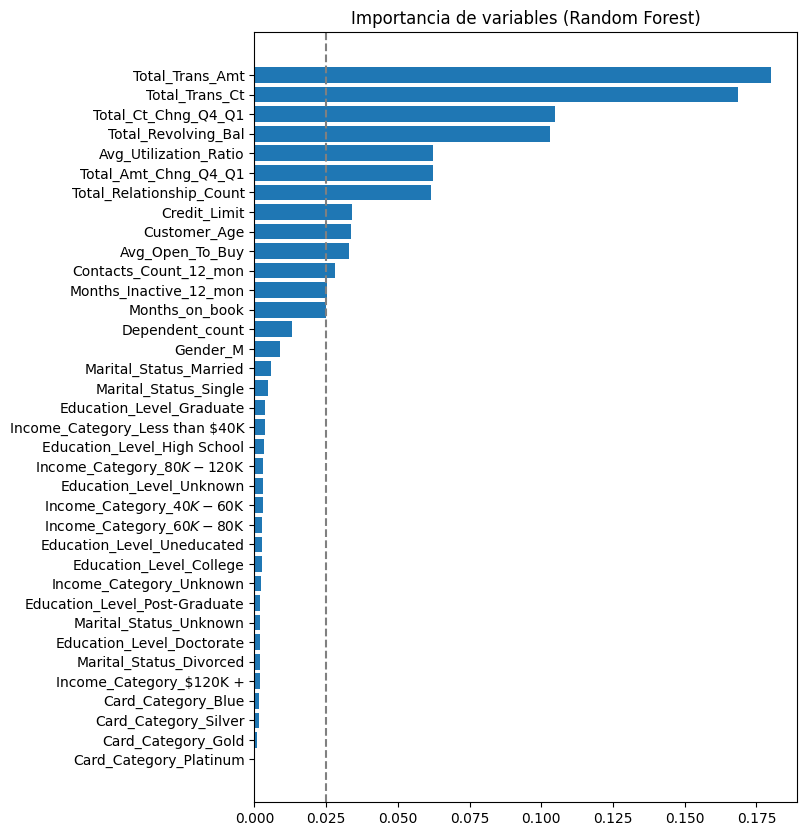

,0
Total_Trans_Amt,0.180063
Total_Trans_Ct,0.168492
Total_Ct_Chng_Q4_Q1,0.104649
Total_Revolving_Bal,0.103123
Avg_Utilization_Ratio,0.062387
Total_Amt_Chng_Q4_Q1,0.062298
Total_Relationship_Count,0.061449
Credit_Limit,0.034077
Customer_Age,0.033833
Avg_Open_To_Buy,0.033068


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_fs = data_num.drop('Abandono', axis=1)
Y_fs = data_num['Abandono']
rf_fs = RandomForestClassifier(n_estimators=300, random_state=1)
rf_fs.fit(X_fs, Y_fs)

importancias = pd.Series(rf_fs.feature_importances_, index=X_fs.columns).sort_values()
plt.figure(figsize=(7,10))
plt.barh(importancias.index, importancias)
plt.axvline(0.025, ls='--', c='gray')
plt.title('Importancia de variables (Random Forest)')
plt.show()
importancias.sort_values(ascending=False).head(15)

In [ ]:
#Tabla resumen para decidir
resumen_fs = pd.DataFrame({'|correlacion|': cor_variable_interes.abs(), 'importancia_RF': importancias})
resumen_fs['relevante'] = (resumen_fs['|correlacion|'] >= 0.1) | (resumen_fs['importancia_RF'] >= 0.025)
resumen_fs.sort_values('importancia_RF', ascending=False).round(3)

,|correlacion|,importancia_RF,relevante
Total_Trans_Amt,0.169,0.180,True
Total_Trans_Ct,0.371,0.168,True
Total_Ct_Chng_Q4_Q1,0.290,0.105,True
Total_Revolving_Bal,0.263,0.103,True
Avg_Utilization_Ratio,0.178,0.062,True
Total_Amt_Chng_Q4_Q1,0.131,0.062,True
Total_Relationship_Count,0.150,0.061,True
Credit_Limit,0.024,0.034,True
Customer_Age,0.018,0.034,True
Avg_Open_To_Buy,0.000,0.033,True


## 3.4 Conclusión de la selección de factores

**Criterio:** una variable se considera relevante si |correlación con abandono| ≥ 0.1 **o** importancia en Random Forest ≥ 0.025,
y luego se quitan las redundantes.

| Decisión | Variables | Razón |
|---|---|---|
| **Se conservan (11)** | `Total_Trans_Ct`, `Total_Trans_Amt`, `Total_Ct_Chng_Q4_Q1`, `Total_Revolving_Bal`, `Avg_Utilization_Ratio`, `Total_Amt_Chng_Q4_Q1`, `Total_Relationship_Count`, `Contacts_Count_12_mon`, `Months_Inactive_12_mon`, `Credit_Limit`, `Customer_Age` | Alta correlación y/o alta importancia |
| Se elimina por redundante | `Avg_Open_To_Buy` (fórmula con `Credit_Limit`), `Months_on_book` (≈0.79 con edad) | Aportan la misma información |
| Se eliminan por irrelevantes | `Gender`, `Dependent_count`, `Education_Level`, `Marital_Status`, `Income_Category`, `Card_Category` | Correlación < 0.04 e importancia < 0.015 |

**Lectura de negocio:** el abandono se explica por el **comportamiento transaccional**, no por el perfil demográfico.
Un cliente que hace **pocas transacciones**, cuya actividad **cae del Q1 al Q4**, que tiene **saldo rotativo bajo**, **pocos productos**
con el banco, más **meses inactivo** y más **contactos** con el banco (posibles quejas) tiene mayor riesgo de irse.

In [ ]:
#Variables seleccionadas
objetivo = 'Attrition_Flag'
predictoras = ['Total_Trans_Ct','Total_Trans_Amt','Total_Ct_Chng_Q4_Q1','Total_Revolving_Bal','Avg_Utilization_Ratio',
               'Total_Amt_Chng_Q4_Q1','Total_Relationship_Count','Contacts_Count_12_mon','Months_Inactive_12_mon',
               'Credit_Limit','Customer_Age']
predictoras_numericas = predictoras  #todas las seleccionadas son numéricas

data = data[predictoras + [objetivo]]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Total_Trans_Ct            10127 non-null  int64   
 1   Total_Trans_Amt           10127 non-null  int64   
 2   Total_Ct_Chng_Q4_Q1       10127 non-null  float64 
 3   Total_Revolving_Bal       10127 non-null  int64   
 4   Avg_Utilization_Ratio     10127 non-null  float64 
 5   Total_Amt_Chng_Q4_Q1      10127 non-null  float64 
 6   Total_Relationship_Count  10127 non-null  int64   
 7   Contacts_Count_12_mon     10127 non-null  int64   
 8   Months_Inactive_12_mon    10127 non-null  int64   
 9   Credit_Limit              10127 non-null  float64 
 10  Customer_Age              10127 non-null  int64   
 11  Attrition_Flag            10127 non-null  category
dtypes: category(1), float64(4), int64(7)
memory usage: 880.4 KB


# 4. Balanceo y codificación

Se balancea con SMOTE para que la clase minoritaria (Attrited Customer) quede en el 50 % de la mayoritaria, igual que en la
práctica de minería. Como después de la selección todas las predictoras son numéricas, se usa `SMOTE` (no es necesario `SMOTENC`).

> **Ojo:** igual que en los notebooks de clase, el balanceo se hace **antes** de la validación cruzada, así que las medidas de las
> secciones 5 y 6 pueden salir algo optimistas. En la sección 6.1 se repite la validación aplicando SMOTE solo dentro de cada fold
> para comprobar qué tan bien generaliza el modelo con clientes reales.

Antes: {'Existing Customer': 8500, 'Attrited Customer': 1627}
Después: {'Existing Customer': 8500, 'Attrited Customer': 4250}


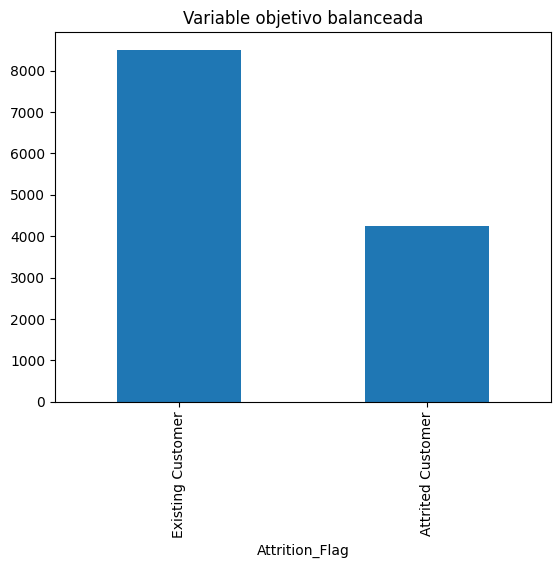

In [ ]:
#Balanceo de datos
from imblearn.over_sampling import SMOTE

#Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis=1)
Y = data[objetivo]

smote = SMOTE(k_neighbors=5, sampling_strategy=0.5, random_state=42)
X_smote, y_smote = smote.fit_resample(X, Y)

# Creamos un dataframe con los resultados (X_smote, y_smote)
data = pd.DataFrame(columns=X_smote.columns.values, data=X_smote)
data[objetivo] = y_smote

print("Antes:", Y.value_counts().to_dict())
print("Después:", data[objetivo].value_counts().to_dict())
data[objetivo].value_counts().plot(kind='bar', title='Variable objetivo balanceada')
plt.show()

In [ ]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data[objetivo] = labelencoder.fit_transform(data[objetivo])
print(dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_))))
data.head()

{'Attrited Customer': np.int64(0), 'Existing Customer': np.int64(1)}


,Total_Trans_Ct,Total_Trans_Amt,Total_Ct_Chng_Q4_Q1,Total_Revolving_Bal,Avg_Utilization_Ratio,Total_Amt_Chng_Q4_Q1,Total_Relationship_Count,Contacts_Count_12_mon,Months_Inactive_12_mon,Credit_Limit,Customer_Age,Attrition_Flag
0,42,1144,1.625,777,0.061,1.335,5,3,1,12691.0,45,1
1,33,1291,3.714,864,0.105,1.541,6,2,1,8256.0,49,1
2,20,1887,2.333,0,0.000,2.594,4,0,1,3418.0,51,1
3,20,1171,2.333,2517,0.760,1.405,3,1,4,3313.0,40,1
4,28,816,2.500,0,0.000,2.175,5,0,1,4716.0,40,1


# 5. (B) Validación cruzada

**Configuración :**
* `StratifiedKFold(n_splits=10, shuffle=True, random_state=42)` → muestreo **estratificado**: cada fold conserva la proporción de clases.
* `cross_validate(..., return_train_score=True)` → se obtienen las medidas en **train** y en **test** de cada fold.
* Medidas: `f1_macro` (medida principal de comparación), `accuracy`, `precision_macro`, `recall_macro` y
  `recall_abandono` (recall de la clase Attrited Customer = 0).

**Regla para overfitting / underfitting:**
* **Overfitting:** la medida en train supera a la de test por **más de 5 puntos porcentuales** → el modelo memoriza.
* **Underfitting:** tanto train como test son bajos (f1 < 0.80 aprox.) → el modelo es demasiado simple.
* **Buen ajuste:** train y test altos y cercanos.

In [ ]:
#Validación Cruzada
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

#Dataframe para comparar los modelos
comparacion_CV = pd.DataFrame()
resumen_modelos = pd.DataFrame()

scoring = {'f1_macro':'f1_macro', 'accuracy':'accuracy', 'precision_macro':'precision_macro', 'recall_macro':'recall_macro',
           'recall_abandono': make_scorer(recall_score, pos_label=0)}  #0 = Attrited Customer
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) #Muestreo estratificado

In [ ]:
#Función de apoyo: resume train vs test y diagnostica overfitting / underfitting
def diagnostico(nombre, scores):
    medias = scores.mean()
    train, test = medias['train_f1_macro'], medias['test_f1_macro']
    brecha = (train - test) * 100
    if brecha > 5:
        estado = 'Overfitting'
    elif test < 0.80:
        estado = 'Underfitting'
    else:
        estado = 'Buen ajuste'
    resumen_modelos[nombre] = [train, test, brecha, medias['test_accuracy'], medias['test_recall_abandono'],
                               medias['fit_time'], estado]
    resumen_modelos.index = ['f1 train', 'f1 test', 'brecha (pp)', 'accuracy test', 'recall abandono test',
                             'tiempo ajuste (s)', 'diagnóstico']
    print(f"{nombre}:  f1 train = {train:.4f} | f1 test = {test:.4f} | brecha = {brecha:.2f} pp  →  {estado}")

In [ ]:
#Se separa variables predictoras y objetivo
X = data.drop(objetivo, axis=1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12750 entries, 0 to 12749
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Total_Trans_Ct            12750 non-null  int64  
 1   Total_Trans_Amt           12750 non-null  int64  
 2   Total_Ct_Chng_Q4_Q1       12750 non-null  float64
 3   Total_Revolving_Bal       12750 non-null  int64  
 4   Avg_Utilization_Ratio     12750 non-null  float64
 5   Total_Amt_Chng_Q4_Q1      12750 non-null  float64
 6   Total_Relationship_Count  12750 non-null  int64  
 7   Contacts_Count_12_mon     12750 non-null  int64  
 8   Months_Inactive_12_mon    12750 non-null  int64  
 9   Credit_Limit              12750 non-null  float64
 10  Customer_Age              12750 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 1.1 MB


## TREE – Árbol de decisión
**Configuración:** `criterion='gini'`, `max_depth=10` (limita la profundidad) y `min_samples_leaf=20` (cada hoja con al menos 20
clientes). Ambos límites controlan el overfitting, que es el principal riesgo de un árbol sin podar.

In [ ]:
#Tree
from sklearn import tree
modelTree = tree.DecisionTreeClassifier(criterion='gini', min_samples_leaf=20, max_depth=10, random_state=42)

scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_recall_abandono,train_recall_abandono
0,0.087654,0.015635,0.925811,0.947540,0.933333,0.953290,0.921586,0.946792,0.930588,0.948301,0.922353,0.933333
1,0.087525,0.012303,0.938800,0.946568,0.945098,0.952418,0.935060,0.945766,0.942941,0.947386,0.936471,0.932288
2,0.081021,0.013207,0.934629,0.945941,0.941961,0.951983,0.935146,0.946264,0.934118,0.945621,0.910588,0.926536
3,0.091948,0.012675,0.930058,0.943676,0.937255,0.949804,0.926394,0.942547,0.934118,0.944837,0.924706,0.929935
4,0.088463,0.011986,0.912902,0.944304,0.922353,0.950240,0.911724,0.942130,0.914118,0.946601,0.889412,0.935686
5,0.083383,0.011932,0.929577,0.944248,0.937255,0.950327,0.928590,0.943228,0.930588,0.945294,0.910588,0.930196
6,0.088571,0.012000,0.927562,0.947042,0.935686,0.952767,0.928071,0.945575,0.927059,0.948562,0.901176,0.935948
7,0.088123,0.012763,0.935997,0.950162,0.942745,0.955556,0.933360,0.948739,0.938824,0.951634,0.927059,0.939869
8,0.096173,0.012269,0.943191,0.947115,0.949804,0.952854,0.945958,0.945840,0.940588,0.948431,0.912941,0.935163
9,0.086294,0.011931,0.939010,0.947978,0.945882,0.953638,0.939798,0.946838,0.938235,0.949150,0.915294,0.935686


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
#Cuidado overfitting, más de 5 puntos porcentuales de diferencia entre la evaluacion de train y de test
print(scores.mean())
diagnostico('Tree', scores)

fit_time                 0.087915
score_time               0.012670
test_f1_macro            0.931754
train_f1_macro           0.946457
test_accuracy            0.939137
train_accuracy           0.952288
test_precision_macro     0.930569
train_precision_macro    0.945372
test_recall_macro        0.933118
train_recall_macro       0.947582
test_recall_abandono     0.915059
train_recall_abandono    0.933464
dtype: float64
Tree:  f1 train = 0.9465 | f1 test = 0.9318 | brecha = 1.47 pp  →  Buen ajuste


In [ ]:
#Se almacena en el df la medida a comparar
comparacion_CV['Tree'] = scores['test_f1_macro']

**Evaluación – Árbol:** f1 test 0.932 frente a 0.946 en train (brecha 1.5 pp): **buen ajuste**. Su recall de abandono es 0.915, es decir
que deja pasar ≈ 8.5 % de los clientes que se van. Es el más interpretable y muy rápido de ajustar, pero queda por debajo de los ensambles.

## RANDOM FOREST
**Configuración:** `n_estimators=100` árboles, cada uno entrenado con el 80 % de los registros (`max_samples=0.8`),
`max_depth=20`, `min_samples_leaf=5`. Al promediar muchos árboles distintos se reduce la varianza respecto a un solo árbol.

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_samples=0.8, criterion='gini',
                                  max_depth=20, min_samples_leaf=5, random_state=42, n_jobs=-1)

scores = cross_validate(model_rf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_recall_abandono,train_recall_abandono
0,1.367153,0.071140,0.951384,0.980703,0.956863,0.982832,0.952195,0.980298,0.950588,0.981111,0.931765,0.975948
1,2.490396,0.064735,0.958932,0.982081,0.963137,0.984052,0.954797,0.981490,0.963529,0.982680,0.964706,0.978562
2,1.502605,0.047864,0.956532,0.981390,0.961569,0.983442,0.959081,0.980953,0.954118,0.981830,0.931765,0.976993
3,1.370159,0.046487,0.956841,0.982871,0.961569,0.984749,0.956049,0.982095,0.957647,0.983660,0.945882,0.980392
4,1.372783,0.048194,0.948093,0.982258,0.953725,0.984227,0.946814,0.982164,0.949412,0.982353,0.936471,0.976732
5,1.393332,0.046986,0.960944,0.980384,0.965490,0.982571,0.963820,0.980574,0.958235,0.980196,0.936471,0.973072
6,1.369834,0.046318,0.958256,0.981883,0.963137,0.983878,0.961420,0.981353,0.955294,0.982418,0.931765,0.978039
7,1.385650,0.046864,0.958602,0.980695,0.963137,0.982832,0.957807,0.980476,0.959412,0.980915,0.948235,0.975163
8,1.521684,0.063148,0.969857,0.981278,0.973333,0.983355,0.972175,0.981184,0.967647,0.981373,0.950588,0.975425
9,2.477120,0.066461,0.961222,0.980990,0.965490,0.983094,0.960686,0.980740,0.961765,0.981242,0.950588,0.975686


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
print(scores.mean())
diagnostico('RF', scores)
comparacion_CV['RF'] = scores['test_f1_macro']

fit_time                 1.625072
score_time               0.054820
test_f1_macro            0.958066
train_f1_macro           0.981453
test_accuracy            0.962745
train_accuracy           0.983503
test_precision_macro     0.958485
train_precision_macro    0.981133
test_recall_macro        0.957765
train_recall_macro       0.981778
test_recall_abandono     0.942824
train_recall_abandono    0.976601
dtype: float64
RF:  f1 train = 0.9815 | f1 test = 0.9581 | brecha = 2.34 pp  →  Buen ajuste


**Evaluación – Random Forest:** f1 test 0.958, train 0.981 (brecha 2.3 pp, la mayor de los seis pero dentro del límite de 5 pp): **buen ajuste**.
Recall de abandono 0.943. Promediar muchos árboles mejora claramente al árbol individual (+2.6 pp de f1) a costa de un tiempo de ajuste bastante mayor que el del árbol.

## XGBOOST
**Configuración:** boosting de árboles: cada árbol nuevo corrige los errores de los anteriores.
`n_estimators=200` árboles, `max_depth=4` (árboles poco profundos), `learning_rate=0.1` (paso de aprendizaje),
`objective='binary:logistic'` por ser clasificación binaria.

In [ ]:
#XGBoost
from xgboost import XGBClassifier

model_xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', n_estimators=200,
                          max_depth=4, learning_rate=0.1, random_state=3, n_jobs=-1)

scores = cross_validate(model_xgb, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_recall_abandono,train_recall_abandono
0,0.309271,0.020784,0.960176,0.983757,0.964706,0.985534,0.961571,0.982827,0.958824,0.984706,0.941176,0.982222
1,0.286408,0.021282,0.968419,0.983835,0.971765,0.985621,0.965825,0.983490,0.971176,0.984183,0.969412,0.979869
2,0.258543,0.021036,0.963716,0.984039,0.967843,0.985795,0.965121,0.983446,0.962353,0.984641,0.945882,0.981176
3,0.260780,0.019781,0.965768,0.984241,0.969412,0.985969,0.963432,0.983463,0.968235,0.985033,0.964706,0.982222
4,0.285455,0.020837,0.954486,0.985119,0.959216,0.986754,0.951051,0.984432,0.958235,0.985817,0.955294,0.983007
5,0.266530,0.020609,0.971765,0.983452,0.974902,0.985272,0.971765,0.982859,0.971765,0.984052,0.962353,0.980392
6,0.260050,0.019903,0.965527,0.982378,0.969412,0.984314,0.966363,0.981695,0.964706,0.983072,0.950588,0.979346
7,0.285278,0.020383,0.969929,0.984443,0.973333,0.986144,0.971061,0.983482,0.968824,0.985425,0.955294,0.983268
8,0.259762,0.023910,0.972533,0.984435,0.975686,0.986144,0.974561,0.983718,0.970588,0.985163,0.955294,0.982222
9,0.259312,0.019934,0.975352,0.983538,0.978039,0.985359,0.974260,0.983287,0.976471,0.983791,0.971765,0.979085


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
print(scores.mean())
diagnostico('XGBoost', scores)
comparacion_CV['XGBoost'] = scores['test_f1_macro']

fit_time                 0.273139
score_time               0.020846
test_f1_macro            0.966767
train_f1_macro           0.983924
test_accuracy            0.970431
train_accuracy           0.985691
test_precision_macro     0.966501
train_precision_macro    0.983270
test_recall_macro        0.967118
train_recall_macro       0.984588
test_recall_abandono     0.957176
train_recall_abandono    0.981281
dtype: float64
XGBoost:  f1 train = 0.9839 | f1 test = 0.9668 | brecha = 1.72 pp  →  Buen ajuste


**Evaluación – XGBoost:** f1 test **0.967**, train 0.984 (brecha 1.7 pp): **buen ajuste**. Es el mejor de los seis en f1, exactitud (0.970)
y recall de abandono (0.957), y entrena rápido.

## KNN
Los modelos basados en distancias (KNN, SVM) y la red neuronal necesitan **variables normalizadas**; si no, las variables con valores
grandes (`Credit_Limit`, `Total_Trans_Amt`) dominarían. Se guarda una copia sin normalizar (`X_original`) para los modelos de árboles.

In [ ]:
#Se guarda una copia sin normalizar para los modelos de árboles
X_original = X.copy()

#Normalizacion las variables numéricas
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X[predictoras_numericas]) #Ajuste de los parametros: max - min
X[predictoras_numericas] = min_max_scaler.transform(X[predictoras_numericas])
X.head()

,Total_Trans_Ct,Total_Trans_Amt,Total_Ct_Chng_Q4_Q1,Total_Revolving_Bal,Avg_Utilization_Ratio,Total_Amt_Chng_Q4_Q1,Total_Relationship_Count,Contacts_Count_12_mon,Months_Inactive_12_mon,Credit_Limit,Customer_Age
0,0.248062,0.035273,0.437534,0.308701,0.061061,0.392994,0.8,0.500000,0.166667,0.340190,0.404255
1,0.178295,0.043452,1.000000,0.343266,0.105105,0.453636,1.0,0.333333,0.166667,0.206112,0.489362
2,0.077519,0.076611,0.628164,0.000000,0.000000,0.763615,0.6,0.000000,0.166667,0.059850,0.531915
3,0.077519,0.036775,0.628164,1.000000,0.760761,0.413600,0.4,0.166667,0.666667,0.056676,0.297872
4,0.139535,0.017025,0.673129,0.000000,0.000000,0.640271,0.8,0.000000,0.166667,0.099091,0.297872


**Configuración:** `n_neighbors=10` vecinos con distancia `euclidean`. Es un método perezoso: no aprende parámetros, clasifica por votación de los vecinos más cercanos.

In [ ]:
#Método Perezoso
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=10, metric='euclidean')

scores = cross_validate(model_knn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_recall_abandono,train_recall_abandono
0,0.145631,0.288556,0.915979,0.927474,0.923922,0.934466,0.909455,0.921393,0.924118,0.934837,0.924706,0.935948
1,0.020958,0.128683,0.910591,0.926724,0.919216,0.933856,0.904779,0.920976,0.917647,0.933595,0.912941,0.932810
2,0.020633,0.126731,0.906600,0.927215,0.915294,0.934379,0.899796,0.921852,0.915294,0.933529,0.915294,0.930980
3,0.020454,0.123175,0.907318,0.926816,0.916078,0.933943,0.900937,0.921086,0.915294,0.933660,0.912941,0.932810
4,0.021966,0.109391,0.896440,0.928577,0.905882,0.935599,0.889287,0.923156,0.905882,0.934967,0.905882,0.933072
5,0.031044,0.204005,0.921490,0.924673,0.929412,0.931939,0.917118,0.918652,0.926471,0.931961,0.917647,0.932026
6,0.030873,0.185218,0.912327,0.927549,0.920784,0.934553,0.906490,0.921561,0.919412,0.934771,0.915294,0.935425
7,0.021224,0.110094,0.912863,0.926442,0.921569,0.933682,0.908217,0.921089,0.918235,0.932745,0.908235,0.929935
8,0.021147,0.107290,0.905383,0.926055,0.914510,0.933333,0.899648,0.920707,0.912353,0.932353,0.905882,0.929412
9,0.020761,0.108597,0.910622,0.925741,0.920000,0.932985,0.907933,0.920083,0.913529,0.932484,0.894118,0.930980


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
print(scores.mean())
diagnostico('Knn', scores)
comparacion_CV['Knn'] = scores['test_f1_macro']

fit_time                 0.035469
score_time               0.149174
test_f1_macro            0.909961
train_f1_macro           0.926727
test_accuracy            0.918667
train_accuracy           0.933874
test_precision_macro     0.904366
train_precision_macro    0.921056
test_recall_macro        0.916824
train_recall_macro       0.933490
test_recall_abandono     0.911294
train_recall_abandono    0.932340
dtype: float64
Knn:  f1 train = 0.9267 | f1 test = 0.9100 | brecha = 1.68 pp  →  Buen ajuste


**Evaluación – KNN:** f1 test 0.910, train 0.927 (brecha 1.7 pp): **buen ajuste**, pero es el de menor calidad. Con 11 variables, sumar
distancias entre clientes separa peor las clases que los umbrales de los árboles. Su ajuste es instantáneo porque no aprende parámetros.

## NN – Red neuronal
**Configuración:** dos capas ocultas de 50 y 10 neuronas (`hidden_layer_sizes=(50,10)`), activación `relu`, optimizador `adam`
con tasa de aprendizaje inicial de 0.01 y hasta 500 iteraciones.

In [ ]:
#Red neuronal
#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, identity, relu
#hidden_layer_sizes=(50,10) -> dos capas ocultas con 50 neuronas y 10 neuronas
#learning_rate_init-> valor tasa de aprendizaje
#max_iter-> iteraciones
#solver-> adam (por defecto); con adam no aplican momentum ni learning_rate, solo learning_rate_init
#random_state-> semilla para generacion numeros seudoaletorios
from sklearn.neural_network import MLPClassifier
model_rn = MLPClassifier(activation='relu', hidden_layer_sizes=(50,10), solver='adam',
                         learning_rate_init=0.01, max_iter=500, random_state=3)

scores = cross_validate(model_rn, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_recall_abandono,train_recall_abandono
0,4.851528,0.017544,0.955079,0.970650,0.960000,0.973943,0.954290,0.971242,0.955882,0.970065,0.943529,0.958431
1,8.981911,0.020731,0.961445,0.976727,0.965490,0.979259,0.958417,0.975514,0.964706,0.977974,0.962353,0.974118
2,6.354549,0.040783,0.955030,0.965551,0.959216,0.968802,0.947364,0.958148,0.964706,0.974706,0.981176,0.992418
3,6.513744,0.016207,0.957136,0.975041,0.961569,0.977691,0.953457,0.972520,0.961176,0.977712,0.960000,0.977778
4,8.166126,0.050148,0.938182,0.958152,0.943529,0.961917,0.928914,0.949426,0.951176,0.969673,0.974118,0.992941
5,6.056282,0.018734,0.971165,0.972954,0.974118,0.975861,0.966918,0.971086,0.975882,0.974902,0.981176,0.972026
6,4.706126,0.016957,0.960032,0.964562,0.964706,0.968715,0.963208,0.967907,0.957059,0.961438,0.934118,0.939608
7,4.472377,0.016613,0.949797,0.961727,0.956078,0.966362,0.957801,0.967382,0.942941,0.956667,0.903529,0.927582
8,4.150984,0.017022,0.962169,0.971376,0.966275,0.974379,0.960850,0.968282,0.963529,0.974706,0.955294,0.975686
9,5.650156,0.019941,0.965807,0.967346,0.969412,0.970632,0.962987,0.962366,0.968824,0.973007,0.967059,0.980131


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
print(scores.mean())
diagnostico('NN', scores)
comparacion_CV['NN'] = scores['test_f1_macro']

fit_time                 5.990378
score_time               0.023468
test_f1_macro            0.957584
train_f1_macro           0.968409
test_accuracy            0.962039
train_accuracy           0.971756
test_precision_macro     0.955421
train_precision_macro    0.966387
test_recall_macro        0.960588
train_recall_macro       0.971085
test_recall_abandono     0.956235
train_recall_abandono    0.969072
dtype: float64
NN:  f1 train = 0.9684 | f1 test = 0.9576 | brecha = 1.08 pp  →  Buen ajuste


**Evaluación – Red neuronal:** f1 test 0.958, train 0.968 (brecha 1.1 pp, la más baja): **buen ajuste** y recall de abandono 0.956, casi igual
al de XGBoost. Es el modelo más lento de entrenar y el menos interpretable.

## SVM
**Configuración:** kernel `rbf` (frontera no lineal) con `C=5` (margen blando: penaliza moderadamente los errores de entrenamiento).

In [ ]:
#SVM
from sklearn.svm import SVC
model_svm = SVC(kernel='rbf', C=5)

scores = cross_validate(model_svm, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores = pd.DataFrame(scores)
scores

,fit_time,score_time,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_recall_abandono,train_recall_abandono
0,3.008164,0.199060,0.920866,0.937512,0.929412,0.944488,0.919434,0.937771,0.922353,0.937255,0.901176,0.915556
1,1.779554,0.186582,0.933329,0.935756,0.940392,0.943007,0.930932,0.936628,0.935882,0.934902,0.922353,0.910588
2,1.787166,0.191494,0.922915,0.937905,0.931765,0.944837,0.924732,0.938164,0.921176,0.937647,0.889412,0.916078
3,3.686321,0.530166,0.918180,0.938162,0.927059,0.945098,0.916988,0.938684,0.919412,0.937647,0.896471,0.915294
4,3.938859,0.522413,0.908343,0.939200,0.918431,0.945969,0.907868,0.939315,0.908824,0.939085,0.880000,0.918431
5,1.822361,0.188586,0.934235,0.936046,0.941961,0.943268,0.937528,0.936948,0.931176,0.935163,0.898824,0.910850
6,1.746835,0.189619,0.940848,0.936080,0.947451,0.943268,0.941108,0.936746,0.940588,0.935425,0.920000,0.911895
7,5.332418,0.400888,0.923190,0.936780,0.931765,0.943878,0.923441,0.937359,0.922941,0.936209,0.896471,0.913203
8,2.498027,0.213565,0.932941,0.934782,0.940392,0.942135,0.932941,0.935593,0.932941,0.933987,0.910588,0.909542
9,2.082756,0.385549,0.928403,0.936208,0.936471,0.943355,0.929172,0.936669,0.927647,0.935752,0.901176,0.912941


In [ ]:
# Promedios para evaluar overfitting comparando medidas de train y test
print(scores.mean())
diagnostico('SVM', scores)
comparacion_CV['SVM'] = scores['test_f1_macro']

fit_time                 2.768246
score_time               0.300792
test_f1_macro            0.926325
train_f1_macro           0.936843
test_accuracy            0.934510
train_accuracy           0.943930
test_precision_macro     0.926414
train_precision_macro    0.937388
test_recall_macro        0.926294
train_recall_macro       0.936307
test_recall_abandono     0.901647
train_recall_abandono    0.913438
dtype: float64
SVM:  f1 train = 0.9368 | f1 test = 0.9263 | brecha = 1.05 pp  →  Buen ajuste


**Evaluación – SVM:** f1 test 0.926, train 0.937 (brecha 1.1 pp): **buen ajuste**, pero con el menor recall de abandono (0.902): deja pasar
≈ 10 % de los clientes que se van.

## 5.1 Comparación de modelos

In [ ]:
#Resumen: train vs test, brecha y diagnóstico de overfitting/underfitting
resumen_modelos

,Tree,RF,XGBoost,Knn,NN,SVM
f1 train,0.946457,0.981453,0.983924,0.926727,0.968409,0.936843
f1 test,0.931754,0.958066,0.966767,0.909961,0.957584,0.926325
brecha (pp),1.470392,2.338706,1.715679,1.676539,1.082438,1.051817
accuracy test,0.939137,0.962745,0.970431,0.918667,0.962039,0.93451
recall abandono test,0.915059,0.942824,0.957176,0.911294,0.956235,0.901647
tiempo ajuste (s),0.087915,1.625072,0.273139,0.035469,5.990378,2.768246
diagnóstico,Buen ajuste,Buen ajuste,Buen ajuste,Buen ajuste,Buen ajuste,Buen ajuste


In [ ]:
#f1_macro de cada fold (test)
comparacion_CV

,Tree,RF,XGBoost,Knn,NN,SVM
0,0.925811,0.951384,0.960176,0.915979,0.955079,0.920866
1,0.938800,0.958932,0.968419,0.910591,0.961445,0.933329
2,0.934629,0.956532,0.963716,0.906600,0.955030,0.922915
3,0.930058,0.956841,0.965768,0.907318,0.957136,0.918180
4,0.912902,0.948093,0.954486,0.896440,0.938182,0.908343
5,0.929577,0.960944,0.971765,0.921490,0.971165,0.934235
6,0.927562,0.958256,0.965527,0.912327,0.960032,0.940848
7,0.935997,0.958602,0.969929,0.912863,0.949797,0.923190
8,0.943191,0.969857,0.972533,0.905383,0.962169,0.932941
9,0.939010,0.961222,0.975352,0.910622,0.965807,0.928403


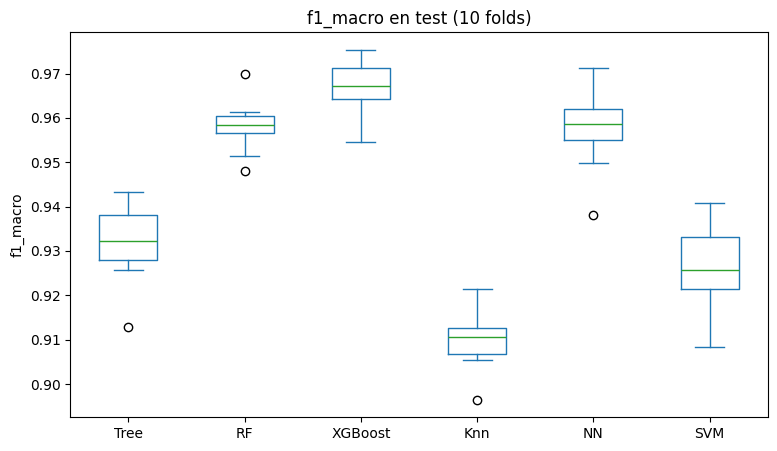

In [ ]:
#Resultados de la validación cruzada
comparacion_CV.plot(kind='box', figsize=(9,5), title='f1_macro en test (10 folds)')
plt.ylabel('f1_macro')
plt.show()

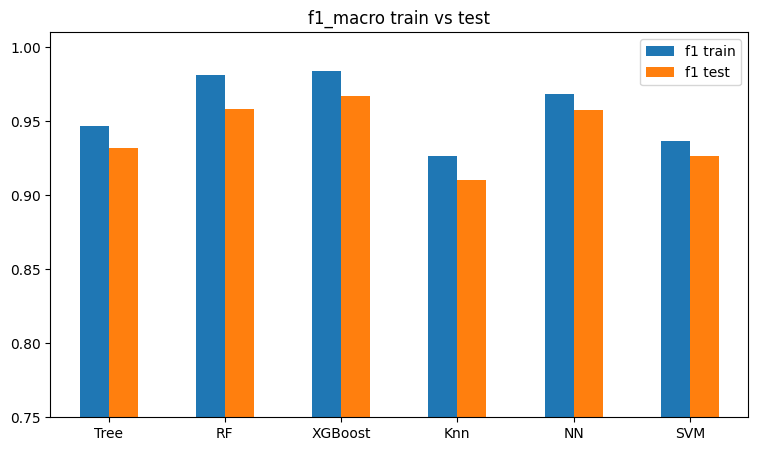

In [ ]:
#Train vs test por modelo
r = resumen_modelos.T[['f1 train','f1 test']].astype(float)
r.plot(kind='bar', figsize=(9,5), ylim=(0.75,1.01), title='f1_macro train vs test')
plt.xticks(rotation=0)
plt.show()

## 5.2 Conclusión sobre la calidad de los modelos

**Todos los modelos presentan buen ajuste:** ninguno supera los 5 puntos porcentuales de diferencia entre train y test
(brechas entre 1.1 y 2.3 pp), y ninguno está en underfitting (todos los f1 de test son mayores a 0.90).

| Modelo | f1 train | f1 test | Brecha | Recall abandono | Lectura |
|---|---|---|---|---|---|
| **XGBoost** | 0.984 | **0.967** | 1.7 pp | **0.957** | Mejor calidad, estable entre folds y rápido |
| Random Forest | 0.981 | 0.958 | 2.3 pp | 0.943 | Segundo; es el de mayor brecha, aunque aceptable |
| Red neuronal | 0.968 | 0.958 | 1.1 pp | 0.956 | Muy cerca del RF, pero es el más lento de entrenar |
| Árbol | 0.946 | 0.932 | 1.5 pp | 0.915 | Bueno y el más interpretable |
| SVM | 0.937 | 0.926 | 1.1 pp | 0.902 | Menor recall de abandono |
| KNN | 0.927 | 0.910 | 1.7 pp | 0.911 | El más bajo |

**Conclusión:** los modelos de *ensamble de árboles* (XGBoost y Random Forest) son los mejores, lo que es coherente con la
selección de factores: la relación entre las variables transaccionales y el abandono es no lineal (umbrales de número de
transacciones, caídas de actividad), algo que los árboles capturan naturalmente. **XGBoost es el mejor modelo**: tiene el mayor
f1_macro, el mayor recall de la clase abandono (detecta ≈96 % de los clientes que se van), una brecha baja y un tiempo de
entrenamiento corto. Por eso es el modelo que se hiperparametriza.

# 6. (C) Hiperparametrización del mejor modelo con GridSearchCV

Se aplica `GridSearchCV` sobre el mejor modelo de la validación cruzada.
Se usa la misma validación estratificada de 10 folds, `scoring='f1_macro'`, `return_train_score=True` para revisar overfitting
y `refit=True` para que el mejor modelo quede reentrenado con el 100 % de los datos.

**Hiperparámetros explorados en XGBoost:**
* `n_estimators`: número de árboles.
* `max_depth`: profundidad de cada árbol (más profundo = más complejo, más riesgo de overfitting).
* `learning_rate`: tamaño del paso de cada árbol.
* `subsample`: proporción de registros que ve cada árbol (introduce aleatoriedad y reduce overfitting).
* `min_child_weight`: peso mínimo en una hoja (evita hojas con muy pocos registros).

In [ ]:
#Configuración hiperparametrización
from sklearn.model_selection import GridSearchCV

modelXGB = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=3, n_jobs=-1)

# Definir los hiperparametros
n_estimators = [200, 400]
max_depth = [3, 5, 7]
learning_rate = [0.05, 0.1]
subsample = [0.8, 1.0]
min_child_weight = [1, 5]

#Hiperparametrización (sobre los datos sin normalizar: los árboles no la necesitan)
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
                  subsample=subsample, min_child_weight=min_child_weight)
grid = GridSearchCV(estimator=modelXGB, param_grid=param_grid, scoring='f1_macro', cv=cv,
                    return_train_score=True, refit=True, n_jobs=-1)
grid.fit(X_original, Y)

#Mejor modelo
modelXGB = grid.best_estimator_

# Mejores párametros
print(grid.best_params_)
print('Combinaciones evaluadas:', len(grid.cv_results_['params']), '× 10 folds')

{'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 0.8}
Combinaciones evaluadas: 48 × 10 folds


In [ ]:
#Revisar overfitting y underfitting
train_best = grid.cv_results_["mean_train_score"][grid.best_index_]
test_best = grid.cv_results_["mean_test_score"][grid.best_index_]
print("Train CV:", round(train_best, 4))
print("Test CV:", round(test_best, 4))
print("Brecha (pp):", round((train_best - test_best)*100, 2))

Train CV: 1.0
Test CV: 0.9751
Brecha (pp): 2.49


In [ ]:
#Top 10 combinaciones
resultados_grid = pd.DataFrame(grid.cv_results_)
resultados_grid['brecha_pp'] = (resultados_grid['mean_train_score'] - resultados_grid['mean_test_score'])*100
resultados_grid[['params','mean_train_score','mean_test_score','brecha_pp','rank_test_score']] \
    .sort_values('rank_test_score').head(10)

,params,mean_train_score,mean_test_score,brecha_pp,rank_test_score
42,"{'learning_rate': 0.1, 'max_depth': 7, 'min_ch...",1.000000,0.975105,2.489495,1
40,"{'learning_rate': 0.1, 'max_depth': 7, 'min_ch...",0.999618,0.974414,2.520336,2
43,"{'learning_rate': 0.1, 'max_depth': 7, 'min_ch...",1.000000,0.973791,2.620903,3
35,"{'learning_rate': 0.1, 'max_depth': 5, 'min_ch...",0.999108,0.973669,2.543872,4
18,"{'learning_rate': 0.05, 'max_depth': 7, 'min_c...",0.999637,0.973256,2.638137,5
34,"{'learning_rate': 0.1, 'max_depth': 5, 'min_ch...",0.999647,0.973071,2.657624,6
19,"{'learning_rate': 0.05, 'max_depth': 7, 'min_c...",0.999422,0.972980,2.644190,7
41,"{'learning_rate': 0.1, 'max_depth': 7, 'min_ch...",0.999461,0.972896,2.656492,8
32,"{'learning_rate': 0.1, 'max_depth': 5, 'min_ch...",0.993881,0.972630,2.125069,9
10,"{'learning_rate': 0.05, 'max_depth': 5, 'min_c...",0.993871,0.972342,2.152886,10


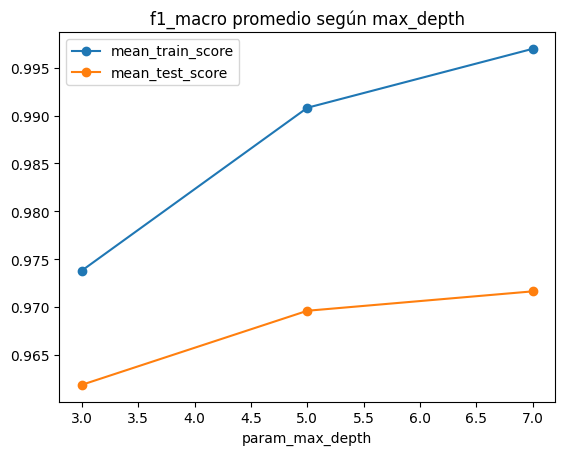

,mean_train_score,mean_test_score
param_max_depth,,
3,0.973814,0.961882
5,0.990821,0.969614
7,0.996982,0.971642


In [ ]:
#Efecto de la profundidad: cuando crece max_depth, train sube más rápido que test (señal de overfitting)
efecto = resultados_grid.groupby('param_max_depth')[['mean_train_score','mean_test_score']].mean()
efecto.plot(marker='o', title='f1_macro promedio según max_depth')
plt.show()
efecto

In [ ]:
#Comparación de medidas: modelo base vs hiperparametrizado
medidas = pd.DataFrame(index=['f1 train CV','f1 test CV','brecha (pp)'])
medidas['XGBoost base'] = [resumen_modelos.loc['f1 train','XGBoost'], resumen_modelos.loc['f1 test','XGBoost'],
                           resumen_modelos.loc['brecha (pp)','XGBoost']]
medidas['XGBoost GridSearch'] = [train_best, test_best, (train_best-test_best)*100]
medidas.astype(float).round(4)

,XGBoost base,XGBoost GridSearch
f1 train CV,0.9839,1.0000
f1 test CV,0.9668,0.9751
brecha (pp),1.7157,2.4895


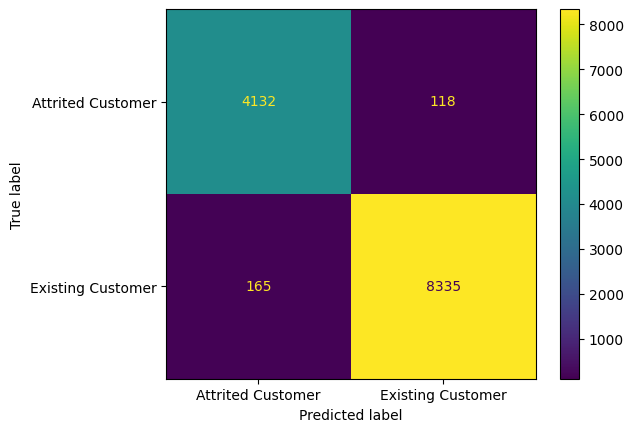

                   precision    recall  f1-score   support

Attrited Customer     0.9616    0.9722    0.9669      4250
Existing Customer     0.9860    0.9806    0.9833      8500

         accuracy                         0.9778     12750
        macro avg     0.9738    0.9764    0.9751     12750
     weighted avg     0.9779    0.9778    0.9778     12750



In [ ]:
#Matriz de confusión y reporte con predicciones de validación cruzada (cada registro se predice cuando está en el fold de test)
from sklearn.model_selection import cross_val_predict
from sklearn import metrics

Y_pred_cv = cross_val_predict(XGBClassifier(**grid.best_params_, objective='binary:logistic', eval_metric='logloss',
                                            random_state=3, n_jobs=-1), X_original, Y, cv=cv)
cm = metrics.confusion_matrix(Y, Y_pred_cv)
metrics.ConfusionMatrixDisplay(cm, display_labels=labelencoder.classes_).plot()
plt.show()
print(metrics.classification_report(Y, Y_pred_cv, target_names=labelencoder.classes_, digits=4))

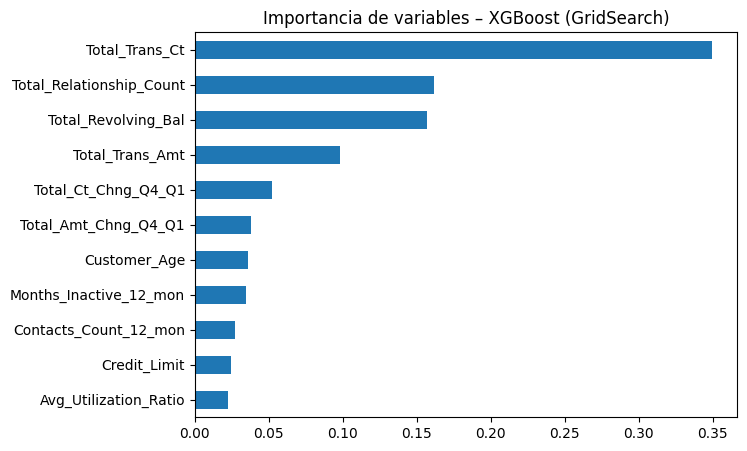

In [ ]:
#Importancia de las variables en el modelo final
pd.Series(grid.best_estimator_.feature_importances_, index=X_original.columns).sort_values().plot(kind='barh', figsize=(7,5),
                                                                                    title='Importancia de variables – XGBoost (GridSearch)')
plt.show()

## 6.1 Validación sin datos sintéticos en tes

En los pasos anteriores, igual que en los notebooks de clase, el balanceo con SMOTE se hizo **antes** de la validación cruzada.
Eso hace que algunos registros sintéticos queden en los folds de prueba y las medidas puedan salir algo optimistas.
Para verificar que el modelo realmente generaliza, se repite la validación aplicando SMOTE **solo dentro del entrenamiento de
cada fold** (Pipeline de imblearn) y evaluando sobre **clientes reales** de la base original.

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

datos_orig = pd.read_csv('BankChurners.csv')
X_real = datos_orig[predictoras]
Y_real = labelencoder.transform(datos_orig[objetivo])

#Candidatos a comparar, ambos salen del GridSearch:
#1) la mejor combinación global  2) la mejor combinación con árboles poco profundos (max_depth=3), más simple
params_mejor = grid.best_params_
params_simple = resultados_grid[resultados_grid['param_max_depth'] == 3].sort_values('rank_test_score').iloc[0]['params']
print('Mejor global :', params_mejor)
print('Mejor simple :', params_simple)

validacion_honesta = pd.DataFrame(index=['f1 train','f1 test (clientes reales)','brecha (pp)','recall abandono test'])
for nombre, params in [('GridSearch mejor global', params_mejor), ('GridSearch max_depth=3', params_simple)]:
    pipe = ImbPipeline([('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
                        ('xgb', XGBClassifier(**params, objective='binary:logistic', eval_metric='logloss',
                                              random_state=3, n_jobs=-1))])
    s_real = pd.DataFrame(cross_validate(pipe, X_real, Y_real, cv=cv, scoring=scoring, return_train_score=True)).mean()
    validacion_honesta[nombre] = [s_real['train_f1_macro'], s_real['test_f1_macro'],
                                  (s_real['train_f1_macro'] - s_real['test_f1_macro'])*100, s_real['test_recall_abandono']]
validacion_honesta.round(4)

Mejor global : {'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 0.8}
Mejor simple : {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 400, 'subsample': 1.0}


,GridSearch mejor global,GridSearch max_depth=3
f1 train,1.0000,0.9744
f1 test (clientes reales),0.9459,0.9450
brecha (pp),5.4053,2.9448
recall abandono test,0.9103,0.9189


## 6.2 Conclusión de la hiperparametrización

* **GridSearchCV** evaluó 48 combinaciones × 10 folds. La mejor combinación (`max_depth=7`, `n_estimators=400`,
  `learning_rate=0.1`, `subsample=0.8`) subió el f1 de test de **0.967 a 0.975**, con una brecha de 2.5 pp, por debajo del
  umbral de 5 pp. Sin embargo, su f1 en train es **1.0**: el modelo ya clasifica perfecto los datos con los que aprende.
* La gráfica de `max_depth` muestra el patrón típico: al aumentar la profundidad, train crece más rápido que test.
* En la **validación honesta** con clientes reales, la mejor combinación global queda con una brecha mayor a 5 pp
  (**overfitting** según la regla de clase). La mejor combinación con `max_depth=3`, también encontrada por el GridSearch,
  logra prácticamente el mismo f1 en test, con una brecha de ≈3 pp.
* **Decisión:** ante una calidad prácticamente igual, se elige el modelo **más simple y con menos overfitting**:
  **XGBoost con `max_depth=3`**. En clientes reales, sin datos sintéticos, su f1_macro es ≈0.945, su exactitud ≈0.97 y
  detecta ≈92 % de los clientes que abandonan. Son valores altos y realistas para el despliegue.

# 7. Modelo final y guardado

In [ ]:
#Modelo seleccionado: XGBoost hiperparametrizado con la combinación max_depth=3 (misma calidad, menos overfitting)
#Se entrena con el 100% de los datos balanceados y sin normalizar
modelo_final = XGBClassifier(**params_simple, objective='binary:logistic', eval_metric='logloss', random_state=3, n_jobs=-1)
modelo_final.fit(X_original, Y)
modelo_final

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
#Se guarda el modelo (mismo formato de clase: modelo, labelencoder, variables, normalizador)
#Nota: el modelo final es de árboles y se entrenó sin normalizar; el scaler se guarda por compatibilidad pero no se aplica
import pickle
filename = 'modelo-attrition.pkl'
variables = X_original.columns.values
pickle.dump([modelo_final, labelencoder, variables, min_max_scaler], open(filename, 'wb'))
print('Modelo guardado en', filename)
print('Variables:', list(variables))

Modelo guardado en modelo-attrition.pkl
Variables: ['Total_Trans_Ct', 'Total_Trans_Amt', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 'Total_Amt_Chng_Q4_Q1', 'Total_Relationship_Count', 'Contacts_Count_12_mon', 'Months_Inactive_12_mon', 'Credit_Limit', 'Customer_Age']


In [ ]:
#Prueba rápida del modelo guardado con dos clientes de la base original
modelo_cargado, le_cargado, variables_cargadas, _ = pickle.load(open(filename, 'rb'))
ejemplo = datos_orig.loc[[0, 21], list(variables_cargadas)]
pred = modelo_cargado.predict(ejemplo)
prob = modelo_cargado.predict_proba(ejemplo)[:, 0]
pd.DataFrame({'real': datos_orig.loc[[0, 21], objetivo].values, 'predicción': le_cargado.inverse_transform(pred),
              'prob. abandono': prob.round(3)})

,real,predicción,prob. abandono
0,Existing Customer,Existing Customer,0.000
1,Attrited Customer,Attrited Customer,0.999


# 9. Conclusiones finales y limitaciones

**Resultado.** Se construyó un modelo que anticipa el abandono de clientes de tarjeta de crédito. El modelo final es un **XGBoost con `max_depth=3`**
(`n_estimators=400`, `learning_rate=0.1`). Con clientes reales y sin datos sintéticos en test obtiene **f1_macro ≈ 0.945**, **exactitud ≈ 0.97**
y detecta **≈ 92 %** de los clientes que abandonan.

**Qué se aprendió.**
* **Calidad:** la base es completa y sin duplicados, pero el 30 % de los registros tiene algún `Unknown` en educación, estado civil o ingreso,
  y trae dos columnas con la respuesta (Naive Bayes) que hubo que eliminar para no hacer trampa.
* **Factores:** el abandono se explica por el **comportamiento transaccional** (número de transacciones, caída de actividad, saldo rotativo,
  productos con el banco, meses inactivo y contactos), no por el perfil demográfico. De 19 variables se pasó a 11.
* **Modelos:** los seis quedaron en buen ajuste (brecha train–test < 5 pp). Los ensambles de árboles ganaron: XGBoost (f1 0.967) y Random Forest (0.958).
* **Hiperparametrización:** el mejor de la malla (`max_depth=7`) llega a f1 0.975 en la validación cruzada con datos balanceados, pero con clientes
  reales cae a 0.946 y su brecha supera los 5 pp. Se eligió `max_depth=3`: misma calidad (0.945) y menos overfitting (≈ 3 pp).

**Limitaciones.**
* Las medidas de las secciones 5 y 6 usan datos balanceados con SMOTE antes de dividir; la validación honesta (6.1) es la cifra a reportar.
* La base es una foto sin fecha: no se sabe a qué periodo corresponden los datos ni cuánto envejecerá el modelo. Conviene reentrenarlo con datos nuevos.
* No se midió el costo real de una campaña de retención. Los niveles de riesgo de la app (30 % y 60 %) son un punto de partida que el negocio debe ajustar.
* La exactitud de los datos frente al banco de origen no se puede verificar: es un dataset público de Kaggle.